[*] Loading preprocessed CSV files...
Loaded X_train shape: (82332, 190), y_train shape: (82332,)
Loaded X_test shape:  (175341, 190), y_test shape:  (175341,)

[*] Training and benchmarking models...
 -> Training: Logistic Regression...
 -> Training: Decision Tree...
 -> Training: Random Forest...

[+] Best Model Selected: Random Forest (Attack Recall: 0.8669)
[+] Best model exported to: ..\models\best_model.joblib
[+] Metrics saved to: ..\models\metrics_summary.json


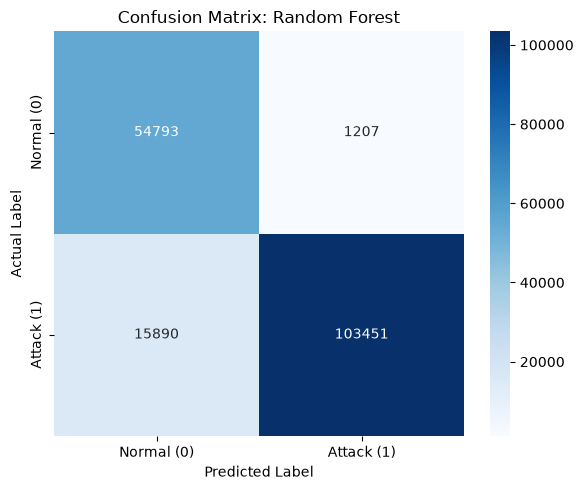

[+] Confusion matrix plot saved to: ..\static\confusion_matrix.png

--- Model Benchmark Summary Table ---
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.878579   0.979116  0.839510  0.903955
Decision Tree        0.893596   0.986631  0.855255  0.916258
Random Forest        0.902493   0.988467  0.866852  0.923674

--- Detailed Security Classification Report (Champion Model) ---
              precision    recall  f1-score   support

      Normal       0.78      0.98      0.87     56000
      Attack       0.99      0.87      0.92    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.89    175341
weighted avg       0.92      0.90      0.90    175341



In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# --- STEP 1: DIRECTORY CONFIGURATION & DATA LOADING ---
processed_dir = os.path.join("..", "data", "processed")
models_dir = os.path.join("..", "models")
static_dir = os.path.join("..", "static")

os.makedirs(models_dir, exist_ok=True)
os.makedirs(static_dir, exist_ok=True)

print("[*] Loading preprocessed CSV files...")
X_train = pd.read_csv(os.path.join(processed_dir, "X_train_processed.csv"))
y_train = pd.read_csv(os.path.join(processed_dir, "y_train.csv"))["label"].values

X_test = pd.read_csv(os.path.join(processed_dir, "X_test_processed.csv"))
y_test = pd.read_csv(os.path.join(processed_dir, "y_test.csv"))["label"].values

print(f"Loaded X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Loaded X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

# --- STEP 2: DEFINE CANDIDATE CLASSIFIERS ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=15, n_jobs=-1, random_state=42
    ),
}

results = {}
best_model_name = None
highest_recall = 0.0
best_model_instance = None

# --- STEP 3: TRAIN AND BENCHMARK MODELS ---
print("\n[*] Training and benchmarking models...")
for name, clf in models.items():
    print(f" -> Training: {name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Calculate key intrusion detection metrics
    acc = float(accuracy_score(y_test, y_pred))
    prec = float(precision_score(y_test, y_pred, zero_division=0))
    rec = float(recall_score(y_test, y_pred, zero_division=0))
    f1 = float(f1_score(y_test, y_pred, zero_division=0))

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

    # Security focus: Maximize Recall to prevent undetected attacks (False Negatives)
    if rec > highest_recall:
        highest_recall = rec
        best_model_name = name
        best_model_instance = clf

print(
    f"\n[+] Best Model Selected: {best_model_name} (Attack Recall: {highest_recall:.4f})"
)

# --- STEP 4: PERSIST BEST MODEL & SUMMARY METRICS ---
joblib.dump(best_model_instance, os.path.join(models_dir, "best_model.joblib"))

with open(os.path.join(models_dir, "metrics_summary.json"), "w") as f:
    json.dump(results, f, indent=4)

print(f"[+] Best model exported to: {os.path.join(models_dir, 'best_model.joblib')}")
print(f"[+] Metrics saved to: {os.path.join(models_dir, 'metrics_summary.json')}")

# --- STEP 5: VISUALIZE AND SAVE CONFUSION MATRIX ---
y_best_pred = best_model_instance.predict(X_test)
cm = confusion_matrix(y_test, y_best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal (0)", "Attack (1)"],
    yticklabels=["Normal (0)", "Attack (1)"],
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

cm_path = os.path.join(static_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"[+] Confusion matrix plot saved to: {cm_path}")

# --- STEP 6: OUTPUT PERFORMANCE SUMMARY & REPORT ---
results_df = pd.DataFrame(results).T
print("\n--- Model Benchmark Summary Table ---")
print(results_df)

print("\n--- Detailed Security Classification Report (Best Model) ---")
print(classification_report(y_test, y_best_pred, target_names=["Normal", "Attack"]))